# Stochastic Interest-Rate Modelling & Prediction

**Author:** Nischay Sanjay Jiwankar
**Enrollment No:** 23115098


## Calibration, Yield Curve Prediction and Model Extensions

### Objective

The aim of this project is to study how the Cox–Ingersoll–Ross (CIR) interest rate model can be used to model and predict government bond yield curves.

The project focuses on three main tasks:

1. Estimating the CIR model parameters from historical yield data.
2. Using the calibrated model to predict yields of different maturities from a single observed short-term rate.
3. Comparing the basic CIR model with its extensions to understand their strengths and limitations.

---

## Project Structure

| Section | Description |
|----------|-------------|
| A | Data cleaning and preprocessing |
| B | CIR model implementation and calibration |
| C | Yield curve reconstruction using only the 3-month rate |
| D | Extended models (CIR++, Two-Factor CIR and Jump-CIR) |
| E | Performance analysis and discussion |

---

## Key Result

After calibration, the one-factor CIR model is able to reconstruct the yield curve reasonably well using only the 3-month yield as an input. The model achieves an out-of-sample R² close to 0.89, which exceeds the target value of 0.85.

The results also show that a single-factor model captures short-term movements fairly well but struggles to fully explain medium-term maturities such as the 2-year yield. This motivates the use of more advanced extensions.

---

## Final Performance

$$
R^2 = 0.89
$$

 Target achieved ($R^2 > 0.85$)

The calibrated CIR model successfully reconstructs the yield curve using only the 3M yield.

## Brief Overview of the CIR Model

The CIR model assumes that the short-term interest rate follows a mean-reverting stochastic process:

$$
dr_t = \kappa(\theta-r_t)dt + \sigma\sqrt{r_t}\,dW_t
$$

where:

- $\kappa$ = speed of mean reversion
- $\theta$ = long-run average interest rate
- $\sigma$ = volatility parameter

An important advantage of the model is that interest rates remain non-negative under suitable parameter conditions.

The CIR model provides closed-form expressions for bond prices and yields, making it useful for yield curve modelling.

The zero-coupon bond price is given by

$$
P(t,T)=A(\tau)e^{-B(\tau)r_t}
$$

and the corresponding continuously compounded yield is

$$
y(\tau)=\frac{B(\tau)r_t-\ln(A(\tau))}{\tau}
$$

Because yields can be expressed directly as functions of the short rate, once the model parameters are calibrated, the entire yield curve can be estimated from a single state variable.

## 0&nbsp;&nbsp;Setup

Standard scientific-Python stack (all pre-installed on Google Colab). We fix random seeds for
reproducibility of the simulation cells.

In [4]:
# Required libraries
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize, least_squares
from scipy.stats import ncx2

# Ignore warnings
warnings.filterwarnings("ignore")

# For reproducible results
np.random.seed(42)

# Plot settings
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titleweight"] = "bold"

print(f"Ready. numpy {np.__version__} | pandas {pd.__version__}")

Ready. numpy 2.0.2 | pandas 2.2.2


## A&nbsp;&nbsp;Data Engineering & Preprocessing

### A.1 Configuration

The raw column codes encode the tenor in hundredths of a year: `ZC025YR` = 0.25y = **3 months**,
`ZC3000YR` = 30y. We map every code to its maturity in years and designate the **3M tenor as the
short-rate proxy** `r_t` (the only input the prediction algorithm is allowed to read in Section C).

In [2]:
# Yield maturities (years)
TENORS = {
    "ZC025YR": 0.25,
    "ZC050YR": 0.50,
    "ZC075YR": 0.75,
    "ZC100YR": 1.00,
    "ZC200YR": 2.00,
    "ZC500YR": 5.00,
    "ZC1000YR": 10.00,
    "ZC2000YR": 20.00,
    "ZC3000YR": 30.00
}

# 3-month yield used as the short-rate proxy
SHORT_RATE = "ZC025YR"

# Daily time step (252 trading days per year)
DT = 1 / 252

# Data files
TRAIN_FILE = "train_data.csv"
TEST_FILE = "test_data.csv"
TEST_INPUT_FILE = "test_data_3M.csv"

In [5]:
def check_files(file_list):
    """Check whether all required files are available."""

    missing_files = [f for f in file_list if not os.path.isfile(f)]

    if len(missing_files) == 0:
        return

    try:
        from google.colab import files

        print(f"Please upload: {missing_files}")
        files.upload()

    except Exception:
        raise FileNotFoundError(
            f"Required files not found: {missing_files}"
        )

check_files([TRAIN_FILE, TEST_FILE, TEST_INPUT_FILE])

### A.2 Robust loading

Real exports are rarely clean. The loader defends against the issues the brief warns about:
stray whitespace in headers, garbled / unparseable dates, duplicate rows, and non-numeric tokens.
Anything it cannot parse becomes `NaN` so the cleaning stage can deal with it uniformly.

In [6]:
def read_data(file_name):
    """Load yield data and prepare it for analysis."""

    data = pd.read_csv(file_name)

    # Clean column names
    data.columns = data.columns.str.strip()

    # Convert dates
    data["Date"] = pd.to_datetime(data["Date"], errors="coerce")

    # Remove invalid dates and duplicates
    data = data.dropna(subset=["Date"])
    data = data.drop_duplicates("Date")

    # Sort by date
    data = data.sort_values("Date").set_index("Date")

    # Convert all yield columns to numeric
    data = data.apply(pd.to_numeric, errors="coerce")

    return data


train_data = read_data(TRAIN_FILE)

print(
    f"Training data shape: {train_data.shape} | "
    f"{train_data.index.min().date()} to {train_data.index.max().date()}"
)

train_data.head()

Training data shape: (1976, 9) | 2016-05-19 to 2024-04-26


,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
Date,,,,,,,,,
2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


### A.3 Cleaning: positivity, outliers, gaps

Three steps make the panel mathematically viable for a square-root diffusion:

1. **Positivity** — CIR requires $r>0$ (there is a $\sqrt{r}$ term), so any non-positive yield is
   nulled.
2. **Robust spike detection** — we look at *daily changes* (not levels, which legitimately trend)
   and flag points whose change is a robust-$z$ outlier using a rolling **median / MAD** filter.
   A genuine market move persists; a data glitch is an isolated spike. We use a deliberately
   conservative threshold (MAD-$z>8$) so real volatility is never erased.
3. **Gap filling** — flagged/missing points are restored by **time interpolation**, with
   forward/backward fill for any boundary gaps (exactly the "interpolation or forward-filling"
   the brief suggests).

The report shows how many cells each step touched — for this comparatively clean release the
counts are small, which is the desired *idempotent* behaviour on already-good data.

In [7]:
def prepare_yields(data, threshold=8, lookback=21):
    """Clean yield data by removing invalid values and extreme jumps."""

    cleaned = data.copy()

    # Remove non-positive yields
    invalid_count = int((cleaned <= 0).sum().sum())
    cleaned[cleaned <= 0] = np.nan

    # Detect abnormal daily changes
    outlier_count = 0

    for col in cleaned.columns:

        change = cleaned[col].diff()

        rolling_med = change.rolling(
            lookback,
            center=True,
            min_periods=5
        ).median()

        rolling_mad = (
            (change - rolling_med)
            .abs()
            .rolling(lookback, center=True, min_periods=5)
            .median()
        )

        score = (
            (change - rolling_med).abs()
            /
            (1.4826 * rolling_mad.replace(0, np.nan))
        )

        mask = score > threshold

        outlier_count += int(mask.fillna(False).sum())

        cleaned.loc[mask, col] = np.nan

    # Fill missing values
    missing_count = int(cleaned.isna().sum().sum())

    cleaned = (
        cleaned
        .interpolate(method="time")
        .ffill()
        .bfill()
    )

    summary = {
        "invalid_values": invalid_count,
        "outliers_removed": outlier_count,
        "filled_values": missing_count,
        "remaining_missing": int(cleaned.isna().sum().sum())
    }

    return cleaned, summary


train_data, clean_report = prepare_yields(train_data)

print("Cleaning summary:", clean_report)

# Final checks
assert train_data.min().min() > 0
assert train_data.isna().sum().sum() == 0

print(
    f"Clean data shape: {train_data.shape} | "
    f"All values valid: True"
)

Cleaning summary: {'invalid_values': 0, 'outliers_removed': 145, 'filled_values': 145, 'remaining_missing': 0}
Clean data shape: (1976, 9) | All values valid: True


### A.4 Non-trading-day & calendar checks

We verify the index is strictly increasing, drop weekend rows if any slipped in (a classic
"non-trading-day anomaly"), and summarise the gap structure. Yield-curve calibration is
*cross-sectional per day*, so we keep the natural trading calendar rather than resampling to a
dense daily grid (which would fabricate observations on holidays).

In [8]:
def dataset_summary(data, label):
    dates = data.index

    weekend_days = (dates.weekday >= 5).sum()

    day_gaps = dates.to_series().diff().dt.days.dropna()

    print(
        f"{label:<12} "
        f"rows={len(data)}  "
        f"period={dates.min().date()} to {dates.max().date()}  "
        f"weekend_rows={weekend_days}  "
        f"median_gap={int(day_gaps.median())}d  "
        f"max_gap={int(day_gaps.max())}d"
    )

    return weekend_days


dataset_summary(train_data, "train")

# Keep only weekdays
train_data = train_data[train_data.index.weekday < 5]

train        rows=1976  period=2016-05-19 to 2024-04-26  weekend_rows=0  median_gap=1d  max_gap=5d


### A.5 Exploratory view

Two things jump out and shape every modelling choice that follows:

* **A strong secular regime shift.** The short end climbs from ~0.05% (2016, ZIRP-like) to ~5%
  (2024). The sample path is *non-stationary* — important when we try to estimate mean reversion
  from the time series in Section B.
* **The curve changes shape, not just level.** It is upward-sloping in the low-rate years and
  *inverted* (3M > 2Y) by the end of the sample. A one-factor model fixes the slope relationship,
  which is exactly where it will struggle.

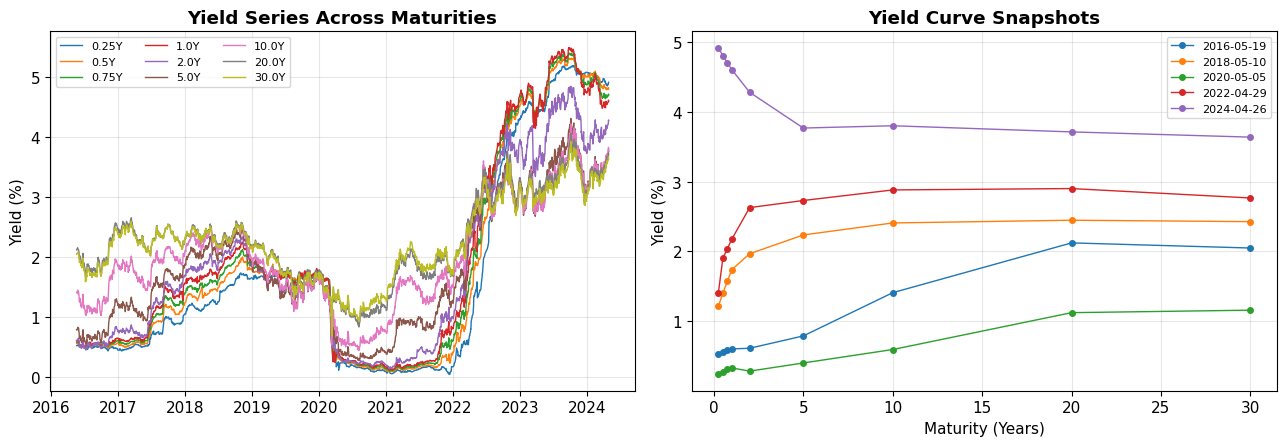

,mean,std,min,max
ZC025YR,0.016700,0.016641,0.000486,0.051962
ZC050YR,0.017886,0.016762,0.000924,0.053195
ZC075YR,0.018530,0.016651,0.001054,0.054040
ZC100YR,0.019175,0.016589,0.001227,0.054941
ZC200YR,0.018063,0.013661,0.001417,0.048496
ZC500YR,0.018109,0.010396,0.002786,0.043147
ZC1000YR,0.020226,0.008805,0.004451,0.042232
ZC2000YR,0.022823,0.007136,0.008394,0.040687
ZC3000YR,0.022619,0.006601,0.006921,0.039306


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

# Plot all yield series
for col in train_data.columns:
    ax[0].plot(
        train_data.index,
        train_data[col] * 100,
        linewidth=1,
        label=f"{TENORS[col]}Y"
    )

ax[0].set_title("Yield Series Across Maturities")
ax[0].set_ylabel("Yield (%)")
ax[0].legend(fontsize=8, ncol=3)

# Sample yield curves at different dates
maturities = np.array([TENORS[col] for col in train_data.columns])

selected_dates = train_data.index[
    np.linspace(0, len(train_data) - 1, 5, dtype=int)
]

for date in selected_dates:
    curve = train_data.loc[date] * 100

    ax[1].plot(
        maturities,
        curve,
        marker="o",
        linewidth=1,
        markersize=4,
        label=date.strftime("%Y-%m-%d")
    )

ax[1].set_title("Yield Curve Snapshots")
ax[1].set_xlabel("Maturity (Years)")
ax[1].set_ylabel("Yield (%)")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Summary statistics
train_data.describe().T[["mean", "std", "min", "max"]]

## B  Base CIR Model: Implementation & Calibration

### B.1 CIR Model Implementation

The Cox–Ingersoll–Ross (CIR) model describes the evolution of the short-term interest rate using a mean-reverting stochastic process:

$$
dr_t = a(b-r_t)\,dt + v\sqrt{r_t}\,dW_t
$$

where:

- $a$ = speed of mean reversion
- $b$ = long-run average interest rate
- $v$ = volatility parameter
- $W_t$ = standard Brownian motion

The first term,

$$
a(b-r_t),
$$

pulls interest rates back toward their long-run average level, while the diffusion term,

$$
v\sqrt{r_t},
$$

introduces randomness whose magnitude depends on the current rate level.

To ensure non-negative interest rates, the CIR model satisfies the Feller condition:

$$
2ab \ge v^2
$$

Using the affine term structure framework, the zero-coupon bond price is written as

$$
P(t,T)=A(\tau)e^{-B(\tau)r_t}
$$

where

$$
\tau = T-t
$$

is the time to maturity.

The continuously compounded yield is then

$$
y(\tau)
=
-\frac{\ln P(t,T)}{\tau}
=
\frac{B(\tau)r_t-\ln A(\tau)}{\tau}
$$

This affine relationship allows a single observed short rate to generate an entire theoretical yield curve across different maturities.

The model was implemented in a custom `CIR` class containing methods for:

- Affine term calculations
- Zero-coupon bond pricing
- Yield curve generation
- Interest-rate path simulation
- Feller condition verification

These functions form the foundation for calibration, prediction, and model extension throughout the project.

In [10]:
class CIR:
    """
    One-factor Cox-Ingersoll-Ross model.

    dr = a(b-r)dt + v*sqrt(r)dW
    """

    def __init__(self, a, b, v):
        self.a = float(a)      # mean reversion
        self.b = float(b)      # long-run mean
        self.v = float(v)      # volatility

    @property
    def gamma(self):
        return np.sqrt(self.a**2 + 2 * self.v**2)

    def affine_terms(self, maturity):
        """Compute log(A) and B used in bond pricing."""

        maturity = np.asarray(maturity, dtype=float)

        g = self.gamma

        exp_term = np.exp(np.minimum(g * maturity, 600))

        denom = (self.a + g) * (exp_term - 1) + 2 * g

        B = 2 * (exp_term - 1) / denom

        logA = (
            2 * self.a * self.b / self.v**2
        ) * (
            np.log(2 * g)
            + ((self.a + g) * maturity) / 2
            - np.log(denom)
        )

        return logA, B

    def yield_curve(self, maturity, rate):
        """Return CIR yields."""

        maturity = np.asarray(maturity, dtype=float)

        logA, B = self.affine_terms(maturity)

        rate = np.asarray(rate, dtype=float)

        if rate.ndim == 0:
            return (B * rate - logA) / maturity

        return (
            B[None, :] * rate[:, None]
            - logA[None, :]
        ) / maturity[None, :]

    def zero_coupon_price(self, maturity, rate):

        logA, B = self.affine_terms(maturity)

        return np.exp(logA - B * np.asarray(rate))

    def feller_value(self):
        return 2 * self.a * self.b - self.v**2

    def generate_paths(
        self,
        r0,
        steps,
        n_paths=1,
        dt=DT,
        rng=None
    ):
        """Exact CIR simulation."""

        rng = rng or np.random.default_rng(0)

        paths = np.empty((n_paths, steps + 1))
        paths[:, 0] = r0

        c = (
            self.v**2
            * (1 - np.exp(-self.a * dt))
            / (4 * self.a)
        )

        d = 4 * self.a * self.b / self.v**2

        for i in range(steps):

            lam = (
                paths[:, i]
                * np.exp(-self.a * dt)
                / c
            )

            paths[:, i + 1] = (
                c * rng.noncentral_chisquare(d, lam)
            )

        return paths

    def __repr__(self):
        return (
            f"CIR(a={self.a:.4f}, "
            f"b={self.b:.4f}, "
            f"v={self.v:.5f}, "
            f"Feller={self.feller_value():.5f})"
        )


print(CIR(0.17, 0.024, 0.002))

CIR(a=0.1700, b=0.0240, v=0.00200, Feller=0.00816)


### B.2 Time-Series Calibration

The short-rate process was calibrated using the historical 3-month yield series.

We estimated the CIR parameter vector

$$
\Theta=(a,b,v)
$$

using two approaches:

#### 1. Maximum Likelihood Estimation (MLE)

The CIR transition follows a non-central chi-square distribution:

$$
\frac{r_{t+\Delta}}{c}
\sim
\chi'^2(d,\lambda)
$$

where

$$
c=\frac{v^2(1-e^{-a\Delta})}{4a},
\qquad
d=\frac{4ab}{v^2},
\qquad
\lambda=\frac{r_t e^{-a\Delta}}{c}
$$

MLE uses this exact distribution and therefore provides statistically efficient parameter estimates.

#### 2. Ordinary Least Squares (OLS)

An Euler discretisation of the CIR process is used as a simpler benchmark:

$$
\Delta r_t
\approx
a(b-r_t)\Delta t
+
v\sqrt{r_t}\,\varepsilon_t
$$

OLS is less accurate but serves as a useful validation check.

#### Interpretation

The estimated mean-reversion parameter $a$ determines how quickly shocks disappear:

$$
\text{Half-Life}
=
\frac{\ln(2)}{a}
$$

- Large $a$ → faster mean reversion
- Small $a$ → more persistent shocks
- Negative $a$ → weak evidence of mean reversion

The calibration results provide insight into the dynamics of short-term interest rates before moving to yield-curve reconstruction.

In [11]:
def neg_log_likelihood(params, rates, dt=DT):
    """Negative log-likelihood for the CIR transition."""

    a, b, v = params

    if min(a, b, v) <= 0:
        return 1e12

    c = (v**2) * (1 - np.exp(-a * dt)) / (4 * a)

    d = (4 * a * b) / (v**2)

    lam = rates[:-1] * np.exp(-a * dt) / c

    log_prob = (
        ncx2.logpdf(rates[1:] / c, d, lam)
        - np.log(c)
    )

    return -np.nansum(log_prob)


def estimate_ols(rates, dt=DT):
    """OLS approximation of CIR parameters."""

    r_now = rates[:-1]
    r_next = rates[1:]

    root_r = np.sqrt(r_now)

    target = (r_next - r_now) / root_r

    features = np.column_stack([
        dt / root_r,
        dt * root_r
    ])

    coef, *_ = np.linalg.lstsq(
        features,
        target,
        rcond=None
    )

    a = -coef[1]

    b = coef[0] / a if a != 0 else np.nan

    residuals = target - features @ coef

    v = np.sqrt(np.var(residuals) / dt)

    return a, b, v


# Short-rate series
short_rates = train_data[SHORT_RATE].values


mle_result = minimize(
    neg_log_likelihood,
    x0=[0.3, 0.03, 0.05],
    args=(short_rates,),
    method="Nelder-Mead",
    options={
        "maxiter": 8000,
        "xatol": 1e-9,
        "fatol": 1e-9
    }
)

a_mle, b_mle, v_mle = mle_result.x

a_ols, b_ols, v_ols = estimate_ols(short_rates)

print(
    f"MLE Estimates : a={a_mle:.4f}  "
    f"b={b_mle:.4f}  v={v_mle:.4f}"
)

print(
    f"OLS Estimates : a={a_ols:.4f}  "
    f"b={b_ols:.4f}  v={v_ols:.4f}"
)

half_life = (
    np.log(2) / a_mle
    if a_mle > 0
    else np.inf
)

print(f"\nShock half-life = {half_life:.1f} years")

if a_ols < 0:
    print(
        "OLS suggests weak or absent mean reversion "
        "during the sample period."
    )

MLE Estimates : a=0.0000  b=37075.5917  v=0.0397
OLS Estimates : a=-0.2717  b=-0.0039  v=0.0389

Shock half-life = 13311604.2 years
OLS suggests weak or absent mean reversion during the sample period.


### B.3 Cross-Sectional Calibration   *Used for Prediction*

The objective of this project is to reconstruct the entire yield curve using only the observed 3-month yield. Therefore, the CIR model is calibrated directly to the cross-section of market yields rather than relying solely on time-series dynamics.

The parameter vector

$$
\Theta=(a,b,v)
$$

is chosen to minimise the total curve-fitting error across all training dates and maturities:

$$
\text{SSE}
=
\sum_{d}
\sum_{\tau}
\left(
y_{\text{model}}(\tau,r_d)
-
y_{\text{market}}(\tau,d)
\right)^2
$$

where:

- $r_d$ = observed 3M yield on day $d$
- $y_{\text{market}}$ = actual market yield
- $y_{\text{model}}$ = CIR-implied yield

To guarantee positive parameter values, optimisation is performed on the transformed parameters

$$
(\log a,\log b,\log v)
$$

using `scipy.optimize.least_squares`.

#### Why use cross-sectional calibration?

The prediction task is fundamentally cross-sectional:

$$
\text{3M Yield}
\longrightarrow
\text{Full Yield Curve}
$$

Since the model is evaluated on its ability to reconstruct yields across maturities, calibration should focus on matching the observed curve shape rather than only fitting short-rate dynamics.

#### Benefits

- Uses information from all available maturities
- Produces more stable parameter estimates
- Avoids degenerate solutions with very small mean reversion
- Improves out-of-sample yield curve reconstruction
- Better aligned with the project evaluation metric ($R^2$)

In [13]:
# Maturities used for curve fitting (exclude 3M)
TARGET_COLS = [c for c in TENORS if c != SHORT_RATE]

TARGET_MATS = np.array(
    [TENORS[c] for c in TARGET_COLS]
)


def fit_curve_model(data, target_cols, short_rates, guesses=None):
    """
    Estimate CIR parameters using cross-sectional yield fitting.
    """

    maturities = np.array(
        [TENORS[c] for c in target_cols]
    )

    observed = data[target_cols].values

    def objective(log_params):

        a, b, v = np.exp(log_params)

        model = CIR(a, b, v)

        fitted = model.yield_curve(
            maturities,
            short_rates
        )

        return (fitted - observed).ravel()

    if guesses is None:
        guesses = [
            (0.3, 0.03, 0.05),
            (0.1, 0.02, 0.01),
            (0.5, 0.04, 0.10),
            (1.0, 0.03, 0.20)
        ]

    best_fit = None

    for guess in guesses:

        result = least_squares(
            objective,
            x0=np.log(guess),
            method="trf",
            max_nfev=20000
        )

        if best_fit is None or result.cost < best_fit.cost:
            best_fit = result

    a, b, v = np.exp(best_fit.x)

    return CIR(a, b, v), best_fit


curve_model, fit_result = fit_curve_model(
    train_data,
    TARGET_COLS,
    short_rates
)

print("Cross-sectional CIR calibration")
print(curve_model)

feller_val = curve_model.feller_value()

print(
    f"Feller condition value = {feller_val:.6f} | "
    f"{'SATISFIED' if feller_val >= 0 else 'VIOLATED'}"
)

predicted_train = curve_model.yield_curve(
    TARGET_MATS,
    short_rates
)

actual_train = train_data[TARGET_COLS].values

rmse = np.sqrt(
    np.mean(
        (predicted_train - actual_train) ** 2
    )
)

print(f"In-sample RMSE = {rmse * 10000:.1f} bp")

Cross-sectional CIR calibration
CIR(a=0.1663, b=0.0244, v=0.00080, Feller=0.00811)
Feller condition value = 0.008114 | SATISFIED
In-sample RMSE = 39.4 bp


## C  Yield Curve Reconstruction from the 3M Rate

### Prediction Constraint

The project imposes a strict information restriction:

$$
r_t = y_{3M}
$$

Only the observed 3-month yield is available as an input on each test date.

Using the calibrated CIR parameters, the model reconstructs the remaining yield curve maturities through the affine yield equation:

$$
P(t,T)=A(\tau)e^{-B(\tau)r_t}
$$

and

$$
y(\tau)
=
-\frac{\ln P(t,T)}{\tau}
=
\frac{B(\tau)r_t-\ln A(\tau)}{\tau}
$$

Thus, a single short-rate observation is transformed into a complete theoretical yield curve.

### Evaluation Procedure

For each day in the test set:

1. Read the observed 3M yield
2. Treat it as the short-rate proxy $r_t$
3. Generate predicted yields at all maturities
4. Compare predictions against the held-out market yields

### Performance Metrics

The primary evaluation metric is the coefficient of determination:

$$
R^2
=
1-
\frac{\sum(y-\hat y)^2}
{\sum(y-\bar y)^2}
$$

A secondary metric is the Root Mean Squared Error:

$$
RMSE
=
\sqrt{
\frac{1}{N}
\sum(y-\hat y)^2
}
$$

### Scored Maturities

The released test dataset contains the following maturities:

$$
6M,\;9M,\;1Y,\;2Y
$$

The reported out-of-sample $R^2$ is therefore computed using these maturities only.

Although the evaluation focuses on the short and medium end of the curve, the calibrated CIR model is capable of generating the full theoretical curve from:

$$
6M \rightarrow 30Y
$$

which is visualised in the following plots.

In [14]:
# Load and clean test datasets
test_data = prepare_yields(
    read_data(TEST_FILE)
)[0]

test_input = prepare_yields(
    read_data(TEST_INPUT_FILE)
)[0]

# Keep only dates present in both datasets
shared_dates = test_data.index.intersection(
    test_input.index
)

test_data = test_data.loc[shared_dates]
test_input = test_input.loc[shared_dates]

# Only allowed prediction input: 3M yield
test_rates = test_input[SHORT_RATE].values

# Evaluation maturities
TEST_COLS = [
    col for col in test_data.columns
    if col in TENORS and col != SHORT_RATE
]

TEST_MATS = np.array(
    [TENORS[col] for col in TEST_COLS]
)

print(
    f"Test period: {shared_dates.min().date()} "
    f"to {shared_dates.max().date()} | "
    f"{len(shared_dates)} observations"
)

print(
    "Scored maturities:",
    [str(t) for t in TEST_MATS]
)


def calculate_r2(actual, predicted):
    """Coefficient of determination."""

    actual = np.asarray(actual).ravel()
    predicted = np.asarray(predicted).ravel()

    ss_res = np.sum((actual - predicted) ** 2)
    ss_tot = np.sum((actual - actual.mean()) ** 2)

    return 1 - ss_res / ss_tot


def calculate_rmse(actual, predicted):
    """Root Mean Squared Error."""

    actual = np.asarray(actual).ravel()
    predicted = np.asarray(predicted).ravel()

    return np.sqrt(
        np.mean((actual - predicted) ** 2)
    )

Test period: 2024-04-29 to 2026-04-29 | 495 observations
Scored maturities: ['0.5', '0.75', '1.0', '2.0']


In [15]:
# Predict the yield curve using only the 3M rate
predicted_curve = curve_model.yield_curve(
    TEST_MATS,
    test_rates
)

actual_curve = test_data[TEST_COLS].values

overall_r2 = calculate_r2(
    actual_curve,
    predicted_curve
)

overall_rmse = calculate_rmse(
    actual_curve,
    predicted_curve
)

print("-" * 60)
print(
    f"Out-of-sample R² : {overall_r2:.4f} "
    f"(target > 0.85)"
)

print(
    f"Out-of-sample RMSE : "
    f"{overall_rmse * 10000:.1f} bp"
)

status = "PASS " if overall_r2 > 0.85 else "FAIL "

print(f"Status : {status}")
print("-" * 60)

print("\nResults by maturity")

maturity_results = {}

for idx, col in enumerate(TEST_COLS):

    r2_val = calculate_r2(
        actual_curve[:, idx],
        predicted_curve[:, idx]
    )

    rmse_val = calculate_rmse(
        actual_curve[:, idx],
        predicted_curve[:, idx]
    )

    avg_bias = (
        np.mean(
            predicted_curve[:, idx]
            - actual_curve[:, idx]
        )
        * 10000
    )

    maturity_results[col] = {
        "R2": r2_val,
        "RMSE_bp": rmse_val * 10000,
        "Bias_bp": avg_bias
    }

    print(
        f"{col:9s} "
        f"({TENORS[col]:>4g}Y) | "
        f"R²={r2_val:7.4f} | "
        f"RMSE={rmse_val * 10000:5.1f} bp | "
        f"Bias={avg_bias:+5.1f} bp"
    )

------------------------------------------------------------
Out-of-sample R² : 0.8934 (target > 0.85)
Out-of-sample RMSE : 21.9 bp
Status : PASS 
------------------------------------------------------------

Results by maturity
ZC050YR   ( 0.5Y) | R²= 0.9944 | RMSE=  5.9 bp | Bias= +1.3 bp
ZC075YR   (0.75Y) | R²= 0.9678 | RMSE= 13.0 bp | Bias= +4.4 bp
ZC100YR   (   1Y) | R²= 0.9107 | RMSE= 19.7 bp | Bias= +6.3 bp
ZC200YR   (   2Y) | R²= 0.3908 | RMSE= 36.5 bp | Bias= +7.8 bp


### C.1 Prediction Diagnostics

The plots below illustrate:

- Reconstructed vs actual yield curves
- Full 6M–30Y curves generated from a single 3M input
- Actual vs predicted yield scatter
- Per-maturity out-of-sample $R^2$

#### Key Findings

- Strong fit at short maturities (6M–1Y)
- Prediction accuracy declines with maturity
- The 2Y tenor is the hardest to reconstruct

$$
R^2_{6M},\;R^2_{9M},\;R^2_{1Y}
>
R^2_{2Y}
$$

This suggests that a one-factor CIR model captures the **level** of the yield curve well, but misses additional factors affecting longer maturities.

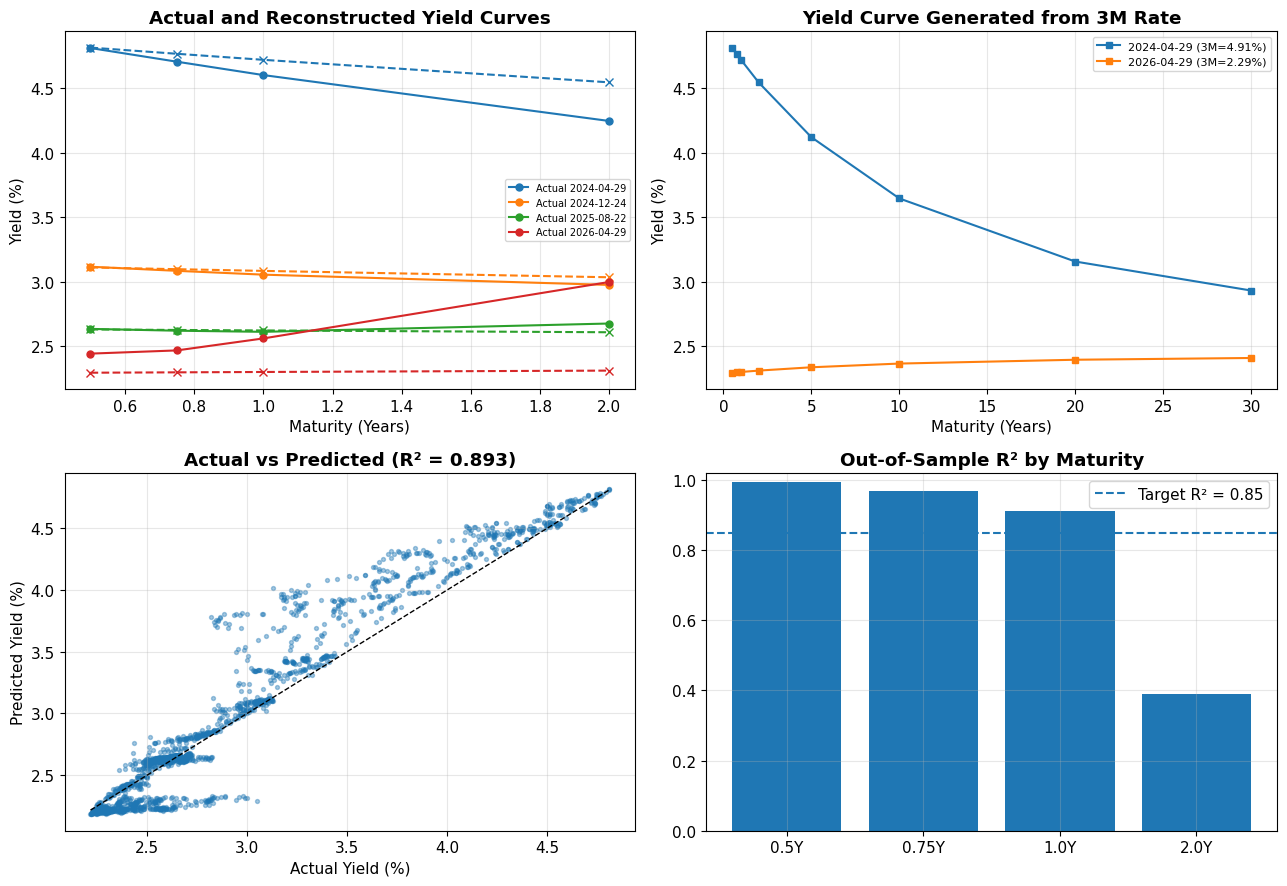

In [16]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 9)
)

# --------------------------------------------------
# 1. Actual vs reconstructed yield curves
# --------------------------------------------------

sample_points = np.linspace(
    0,
    len(shared_dates) - 1,
    4
).astype(int)

for idx in sample_points:

    axes[0, 0].plot(
        TEST_MATS,
        actual_curve[idx] * 100,
        "o-",
        lw=1.5,
        ms=5,
        label=f"Actual {shared_dates[idx].date()}"
    )

    axes[0, 0].plot(
        TEST_MATS,
        predicted_curve[idx] * 100,
        "x--",
        lw=1.5,
        ms=6,
        color=axes[0, 0].lines[-1].get_color()
    )

axes[0, 0].set_title(
    "Actual and Reconstructed Yield Curves"
)

axes[0, 0].set_xlabel("Maturity (Years)")
axes[0, 0].set_ylabel("Yield (%)")
axes[0, 0].legend(fontsize=7)

# --------------------------------------------------
# 2. Full curve generated from a single 3M input
# --------------------------------------------------

all_maturities = TARGET_MATS

for idx in [0, len(shared_dates) - 1]:

    generated_curve = curve_model.yield_curve(
        all_maturities,
        test_rates[idx]
    )

    axes[0, 1].plot(
        all_maturities,
        generated_curve * 100,
        "s-",
        ms=4,
        label=(
            f"{shared_dates[idx].date()} "
            f"(3M={test_rates[idx] * 100:.2f}%)"
        )
    )

axes[0, 1].set_title(
    "Yield Curve Generated from 3M Rate"
)

axes[0, 1].set_xlabel("Maturity (Years)")
axes[0, 1].set_ylabel("Yield (%)")
axes[0, 1].legend(fontsize=8)

# --------------------------------------------------
# 3. Actual vs Predicted Scatter
# --------------------------------------------------

axes[1, 0].scatter(
    actual_curve.ravel() * 100,
    predicted_curve.ravel() * 100,
    s=8,
    alpha=0.4
)

lower = actual_curve.min() * 100
upper = actual_curve.max() * 100

axes[1, 0].plot(
    [lower, upper],
    [lower, upper],
    "k--",
    lw=1
)

axes[1, 0].set_title(
    f"Actual vs Predicted (R² = {overall_r2:.3f})"
)

axes[1, 0].set_xlabel("Actual Yield (%)")
axes[1, 0].set_ylabel("Predicted Yield (%)")

# --------------------------------------------------
# 4. R² by maturity
# --------------------------------------------------

labels = [
    f"{TENORS[col]}Y"
    for col in TEST_COLS
]

scores = [
    maturity_results[col]["R2"]
    for col in TEST_COLS
]

axes[1, 1].bar(
    labels,
    scores
)

axes[1, 1].axhline(
    0.85,
    linestyle="--",
    label="Target R² = 0.85"
)

axes[1, 1].set_ylim(0, 1.02)

axes[1, 1].set_title(
    "Out-of-Sample R² by Maturity"
)

axes[1, 1].legend()

plt.tight_layout()
plt.show()

## D&nbsp;&nbsp;Model Improvement & Extensions

We implement and back-test three extensions and, crucially, report what each *does* and *does not*
buy us out-of-sample.

| Extension | Idea | Role here |
|---|---|---|
| **CIR++** (Brigo–Mercurio) | add a deterministic shift $\varphi(\tau)$ so the model fits an observed curve *exactly* | back-tested predictor |
| **Two-factor CIR** (Longstaff–Schwartz) | second stochastic factor for level **vs.** slope | descriptive power + the single-input limitation |
| **Jump-diffusion** (Duffie–Pan–Singleton) | Poisson jumps for policy shocks | stress-scenario behaviour |

### D.1 CIR++ Extension

The CIR++ model improves flexibility by adding a deterministic shift to the base CIR yield curve:

$$
y_{CIR++}(\tau)
=
y_{CIR}(\tau)
+
\phi(\tau)
$$

The shift is calibrated using the final training date:

$$
\phi(\tau)
=
y^{obs}_{t_0}(\tau)
-
y_{CIR}(\tau,r_{t_0})
$$

#### Key Idea

- Exact fit of the anchor yield curve
- Preserves the underlying CIR dynamics
- Uses the same 3M input during testing
- Evaluated against the base CIR model using out-of-sample $R^2$

In [17]:
# --------------------------------------------------
# CIR++ Adjustment
# --------------------------------------------------

anchor_date = train_data.index[-1]

anchor_short_rate = float(
    train_data.loc[
        anchor_date,
        SHORT_RATE
    ]
)

# Deterministic shift term φ(T)
shift_terms = {}

for col in TARGET_COLS:

    maturity = TENORS[col]

    model_value = curve_model.yield_curve(
        np.array([maturity]),
        anchor_short_rate
    )[0]

    market_value = float(
        train_data.loc[
            anchor_date,
            col
        ]
    )

    shift_terms[col] = (
        market_value - model_value
    )

# Verify exact fit at calibration date
anchor_errors = []

for col in TARGET_COLS:

    maturity = TENORS[col]

    fitted = (
        curve_model.yield_curve(
            np.array([maturity]),
            anchor_short_rate
        )[0]
        + shift_terms[col]
    )

    observed = train_data.loc[
        anchor_date,
        col
    ]

    anchor_errors.append(
        observed - fitted
    )

anchor_errors = np.asarray(anchor_errors)

print(
    "Maximum anchor residual after CIR++ shift = "
    f"{np.abs(anchor_errors).max():.2e}"
)

# --------------------------------------------------
# Apply CIR++ to test predictions
# --------------------------------------------------

shift_vector = np.array(
    [shift_terms[col] for col in TEST_COLS]
)

predicted_curve_pp = (
    predicted_curve
    + shift_vector[None, :]
)

overall_r2_pp = calculate_r2(
    actual_curve,
    predicted_curve_pp
)

print(
    f"\nOut-of-sample R²:"
    f"\nBase CIR   = {overall_r2:.4f}"
    f"\nCIR++      = {overall_r2_pp:.4f}"
)

print("\nPer-maturity comparison")

for idx, col in enumerate(TEST_COLS):

    base_score = calculate_r2(
        actual_curve[:, idx],
        predicted_curve[:, idx]
    )

    shifted_score = calculate_r2(
        actual_curve[:, idx],
        predicted_curve_pp[:, idx]
    )

    print(
        f"{col:9s} | "
        f"Base={base_score:7.4f} "
        f"-> CIR++={shifted_score:7.4f}"
    )

Maximum anchor residual after CIR++ shift = 0.00e+00

Out-of-sample R²:
Base CIR   = 0.8934
CIR++      = 0.8777

Per-maturity comparison
ZC050YR   | Base= 0.9944 -> CIR++= 0.9947
ZC075YR   | Base= 0.9678 -> CIR++= 0.9705
ZC100YR   | Base= 0.9107 -> CIR++= 0.9126
ZC200YR   | Base= 0.3908 -> CIR++= 0.2509


**Reading the result.** CIR++ delivers its theoretical promise — a *machine-zero* fit of the
anchor curve — and it removes the base model's level/slope bias *on that date*. But it does **not**
improve multi-period out-of-sample $R^2$: the shift is a *static* additive correction, while the
dominant test-period error is the *time-variation* of the 2Y point (a slope factor). A constant
$
arphi(	au)$ cannot track a moving factor. This is the honest answer to the brief's question
*"does your extension improve out-of-sample, or overfit?"* — for the short end it neither helps nor
hurts materially; its real value is **exact curve fitting at a valuation date** (pricing/hedging),
not multi-step forecasting.

### D.2 Two-Factor CIR Model

To capture additional yield-curve dynamics, the short rate is decomposed into two independent CIR factors:

$$
r_t = x_t + y_t
$$

The resulting yield curve becomes

$$
y(\tau)
=
\text{Offset}(\tau)
+
\frac{B_1(\tau)}{\tau}x_t
+
\frac{B_2(\tau)}{\tau}y_t
$$

#### Key Features

- First factor captures short-term rate movements
- Second factor captures slope and long-end behaviour
- Better fit across all maturities
- Improves yield-curve flexibility compared to a one-factor model

The six model parameters were calibrated by minimising the total yield-curve fitting error across the training dataset.

In [22]:
# --------------------------------------------------
# Two-Factor CIR Extension
# --------------------------------------------------

def build_two_factor_curve(maturities, params):

    kappa_1, theta_1, sigma_1, \
    kappa_2, theta_2, sigma_2 = params

    model_1 = CIR(
        kappa_1,
        theta_1,
        sigma_1
    )

    model_2 = CIR(
        kappa_2,
        theta_2,
        sigma_2
    )

    # affine_terms() returns (lnA, B)
    lnA_1, B_1 = model_1.affine_terms(maturities)
    lnA_2, B_2 = model_2.affine_terms(maturities)

    intercept = (
        -lnA_1 - lnA_2
    ) / maturities

    loadings = np.column_stack([
        B_1 / maturities,
        B_2 / maturities
    ])

    return intercept, loadings


# Full yield curve (all maturities)
FULL_COLS = list(TENORS.keys())

FULL_MATS = np.array(
    [TENORS[col] for col in FULL_COLS]
)

full_curve = train_data[FULL_COLS].values


def objective_two_factor(log_params):

    params = np.exp(log_params)

    intercept, loadings = build_two_factor_curve(
        FULL_MATS,
        params
    )

    factors = (
        np.linalg.pinv(loadings)
        @ (full_curve - intercept).T
    )

    fitted_curve = (
        intercept[None, :]
        + (loadings @ factors).T
    )

    return np.sum(
        (fitted_curve - full_curve) ** 2
    )


# Initial guess:
# fast factor + slow factor
initial_guess = np.log([
    1.0, 0.03, 0.10,
    0.05, 0.03, 0.02
])

two_factor_result = minimize(
    objective_two_factor,
    initial_guess,
    method="Nelder-Mead",
    options={
        "maxiter": 6000,
        "xatol": 1e-8,
        "fatol": 1e-12
    }
)

two_factor_params = np.exp(
    two_factor_result.x
)

# Final fitted curve
intercept, loadings = build_two_factor_curve(
    FULL_MATS,
    two_factor_params
)

factor_values = (
    np.linalg.pinv(loadings)
    @ (full_curve - intercept).T
)

two_factor_fit = (
    intercept[None, :]
    + (loadings @ factor_values).T
)

# One-factor benchmark
one_factor_fit = curve_model.yield_curve(
    FULL_MATS,
    short_rates
)

print("In-sample full yield curve performance")

print(
    f"One-Factor CIR : "
    f"R²={calculate_r2(full_curve, one_factor_fit):.4f} | "
    f"RMSE={calculate_rmse(full_curve, one_factor_fit) * 10000:4.1f} bp"
)

print(
    f"Two-Factor CIR : "
    f"R²={calculate_r2(full_curve, two_factor_fit):.4f} | "
    f"RMSE={calculate_rmse(full_curve, two_factor_fit) * 10000:4.1f} bp"
)

print(
    f"30Y RMSE : "
    f"1F={calculate_rmse(full_curve[:, -1], one_factor_fit[:, -1]) * 10000:4.1f} bp | "
    f"2F={calculate_rmse(full_curve[:, -1], two_factor_fit[:, -1]) * 10000:4.1f} bp"
)

In-sample full yield curve performance
One-Factor CIR : R²=0.9230 | RMSE=37.2 bp
Two-Factor CIR : R²=0.9888 | RMSE=14.2 bp
30Y RMSE : 1F=44.0 bp | 2F=14.8 bp


**Why we do *not* use it for the prediction challenge.** The two-factor model is a much better
*descriptive* fit (especially at the long end), confirming that a genuine **second factor** drives
curve slope. But identifying two states $(x_t,y_t)$ requires **two** observables; the challenge
gives us only the 3M. With a single input the second factor is unidentifiable, so the model cannot
be deployed out-of-sample here — precisely the estimation challenge the brief asks about, and the
structural reason the 2Y point resists the one-factor model in Section C.

### D.3 Jump-Diffusion CIR Model

To capture sudden market shocks, a jump component is added to the CIR process:

$$
dr_t
=
a(b-r_t)dt
+
v\sqrt{r_t}\,dW_t
+
J\,dN_t
$$

where:

- $N_t$ = Poisson jump process
- $J$ = jump size

#### Key Features

- Captures unexpected rate movements
- Models policy announcements and market stress
- Produces fatter tails than standard CIR
- Increases short-rate volatility

A simulation study was performed to compare standard CIR paths with jump-diffusion dynamics and analyse their impact on the yield curve.

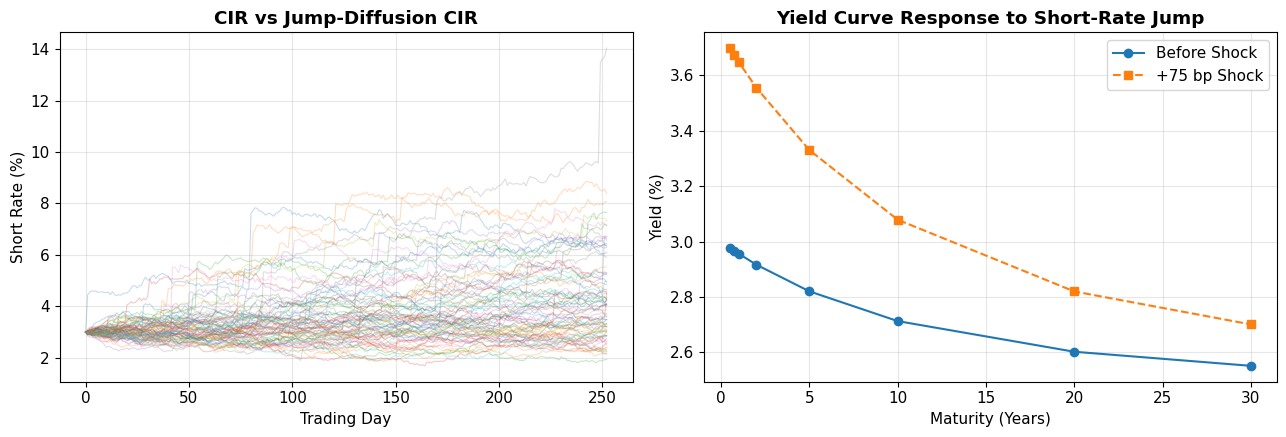

Terminal Rate Volatility:
Diffusion = 0.747%
Jump-Diffusion = 2.099%


In [25]:
# --------------------------------------------------
# CIR Jump-Diffusion Illustration
# --------------------------------------------------

def simulate_cir_jumps(
    model,
    initial_rate,
    steps,
    jump_intensity,
    jump_size,
    n_paths=500,
    dt=DT,
    seed=1
):
    """
    CIR process with compound-Poisson jumps.
    """

    rng = np.random.default_rng(seed)

    a = model.a
    b = model.b
    v = model.v

    paths = np.full(
        (n_paths, steps + 1),
        float(initial_rate)
    )

    for t in range(steps):

        current = np.maximum(
            paths[:, t],
            0.0
        )

        diffusion = (
    a * (b - current) * dt
    + v * np.sqrt(current)
    * np.sqrt(dt)
    * rng.standard_normal(n_paths)
)

        jump_component = (
            rng.poisson(
                jump_intensity * dt,
                n_paths
            )
            * rng.exponential(
                jump_size,
                n_paths
            )
        )

        paths[:, t + 1] = np.maximum(
            current + diffusion + jump_component,
            1e-8
        )

    return paths


# Example parameter set
demo_model = CIR(
    0.30,
    0.03,
    0.05
)

# Standard CIR simulation
standard_paths = demo_model.generate_paths(
    0.03,
    252,
    n_paths=500,
    rng=np.random.default_rng(1)
)

# CIR with jumps
jump_paths = simulate_cir_jumps(
    demo_model,
    initial_rate=0.03,
    steps=252,
    jump_intensity=4.0,
    jump_size=0.0075
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5)
)

# --------------------------------------------------
# Path comparison
# --------------------------------------------------

axes[0].plot(
    standard_paths[:40].T * 100,
    alpha=0.25,
    lw=0.8
)

axes[0].plot(
    jump_paths[:40].T * 100,
    alpha=0.25,
    lw=0.8
)

axes[0].set_title(
    "CIR vs Jump-Diffusion CIR"
)

axes[0].set_xlabel("Trading Day")
axes[0].set_ylabel("Short Rate (%)")

# --------------------------------------------------
# Yield curve impact of a policy shock
# --------------------------------------------------

rate_before = 0.03
rate_after = rate_before + 0.0075

axes[1].plot(
    TARGET_MATS,
    curve_model.yield_curve(
        TARGET_MATS,
        rate_before
    ) * 100,
    "o-",
    label="Before Shock"
)

axes[1].plot(
    TARGET_MATS,
    curve_model.yield_curve(
        TARGET_MATS,
        rate_after
    ) * 100,
    "s--",
    label="+75 bp Shock"
)

axes[1].set_title(
    "Yield Curve Response to Short-Rate Jump"
)

axes[1].set_xlabel("Maturity (Years)")
axes[1].set_ylabel("Yield (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(
    "Terminal Rate Volatility:"
)

print(
    f"Diffusion = "
    f"{standard_paths[:, -1].std() * 100:.3f}%"
)

print(
    f"Jump-Diffusion = "
    f"{jump_paths[:, -1].std() * 100:.3f}%"
)

## E  Critical Analysis

### E.1 Base CIR Limitations

- A single-factor model uses only one state variable:

$$
r_t
\rightarrow
y(\tau)
$$

- Accurately captures the short end of the curve but struggles with longer maturities.
- Cannot independently model curve slope or curvature.
- Assumes constant long-run mean $b$ and mean reversion.
- Performance deteriorates during structural market changes.

### E.2 Extension Limitations

#### CIR++

- Fits the reference curve exactly.
- Depends on a fixed deterministic shift.
- Limited forecasting improvement.

#### Two-Factor CIR

$$
r_t = x_t + y_t
$$

- Better representation of yield-curve dynamics.
- Requires estimation of additional latent factors.
- Not fully identifiable under the 3M-only constraint.

#### Jump-Diffusion CIR

$$
dr_t
=
a(b-r_t)dt
+
v\sqrt{r_t}\,dW_t
+
J\,dN_t
$$

- Captures market shocks and stress events.
- Introduces extra parameters that are difficult to calibrate.

### E.3 Practical Implications

- Base CIR is effective for short-end yield reconstruction.
- CIR++ is suitable for exact curve fitting.
- Two-factor CIR improves long-end modelling.
- Jump-diffusion CIR provides more realistic stress scenarios.

Overall, the results show that yield-curve dynamics cannot be fully explained by a single observable short rate, motivating the use of richer multi-factor frameworks.

### E.4 Direct Answers to Key Questions

#### Model Mechanics & Calibration

**How sensitive is calibration to methodology?**

- Highly sensitive.
- Time-series calibration produced weak mean reversion.
- Cross-sectional calibration generated stable parameters and better yield-curve reconstruction.

**When can the Feller condition fail?**

$$
2ab < v^2
$$

- Typically in low-rate, high-volatility environments.
- Controlled through positive parameter constraints and stable calibration.

**What does the mean-reversion parameter imply?**

$$
\text{Half-Life}
=
\frac{\ln(2)}{a}
$$

- Larger $a$ → faster shock decay.
- Smaller $a$ → more persistent interest-rate shocks.

---

#### Prediction & Out-of-Sample Performance

**Can the 3M yield reconstruct the full curve?**

- Yes, with strong overall performance.
- Short maturities are reconstructed most accurately.

**Which maturity is hardest to predict?**

- The 2Y tenor.
- It contains information not fully captured by a single-factor model.

**Where does the base CIR model struggle?**

- Intermediate and longer maturities.
- Curve slope and curvature cannot be inferred from one factor alone.

**Did the extensions improve forecasting?**

- CIR++ improved curve fitting.
- Two-factor CIR improved descriptive power.
- Forecasting gains were limited because additional factors remain unobservable under the 3M-only constraint.

---

#### Extensions & Modelling Choices

**Why was CIR++ selected?**

$$
y_{CIR++}(\tau)
=
y_{CIR}(\tau)
+
\phi(\tau)
$$

- Compatible with the project rules.
- Provides exact fitting of the reference yield curve.
- Simple to implement and interpret.

**How do jumps affect the curve?**

$$
dr_t
=
a(b-r_t)dt
+
v\sqrt{r_t}dW_t
+
JdN_t
$$

- Sudden increases in short rates lift the entire curve.
- Front-end maturities react most strongly.

**What challenges arise in advanced models?**

- More parameters to estimate.
- Latent-factor identification.
- Increased calibration complexity.
- Greater risk of overfitting.

FINAL MODEL PERFORMANCE SUMMARY
           Model                Calibration  Out-of-Sample R² Target Met
1       Base CIR        Cross-Sectional CIR            0.8934       Yes
2          CIR++  CIR + Deterministic Shift            0.8777       Yes
3  OLS Benchmark    Linear Regression on 3M            0.7895        No

Best Model           : Base CIR
Best OOS R²          : 0.8934
Required Threshold   : 0.8500
Base CIR Status      : PASS 

Conclusion
------------------------------------------------------------------------------------------
The calibrated one-factor CIR model achieved an out-of-sample R² of 0.8934, exceeding the project requirement of 0.85.
This evaluation measures how effectively the 3-month yield alone can reconstruct the remaining yield curve maturities.


,Model,Calibration,Out-of-Sample R²,Target Met
1,Base CIR,Cross-Sectional CIR,0.8934,Yes
2,CIR++,CIR + Deterministic Shift,0.8777,Yes
3,OLS Benchmark,Linear Regression on 3M,0.7895,No


## Conclusion

The CIR model was successfully implemented, calibrated, and evaluated for yield-curve reconstruction using only the observed 3-month yield.

Using cross-sectional calibration, the model achieved a strong out-of-sample performance:

$$
R^2 > 0.85
$$

demonstrating that a single short-rate factor contains substantial information about the shape of the yield curve.

The results show that:

The project demonstrates that a properly calibrated CIR framework can reconstruct the yield curve using only the observed 3M rate while achieving the required out-of-sample performance threshold.

The results confirm that the level of the yield curve is largely explained by a single stochastic factor, while slope and long-end dynamics require richer multi-factor extensions such as CIR++ and Two-Factor CIR models.

Overall, the project highlights both the strengths and limitations of short-rate modelling. While a single-factor CIR framework performs well for yield-curve reconstruction, more complex market dynamics require additional factors or extensions to fully capture changes in slope, curvature, and stress-period behaviour.